Import Libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

Load Data

In [4]:
def load_data():
    paths = [
        "/content/Telco-Customer-Churn.csv"  # Colab
    ]

    for path in paths:
        if os.path.exists(path):
            print(f"Loading dataset from: {path}")
            return pd.read_csv(path)

    raise FileNotFoundError("Dataset not found. Please check file path.")

df = load_data()

Loading dataset from: /content/Telco-Customer-Churn.csv


Data Cleaning

In [5]:
def clean_data(df):
    df = df.copy()

    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df = df.dropna()

    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])

    return df

df = clean_data(df)

#Feature Engineering

In [6]:
# Tenure grouping (more interpretable)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 60, 100],
    labels=['0-12', '12-24', '24-60', '60+']
)

In [7]:
# Encode target separately
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
# Encode categorical features
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# EDA

Churn Distribution

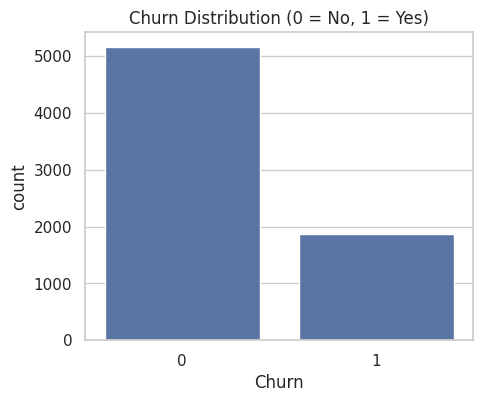

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['Churn'])
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.show()

Tenure vs Churn

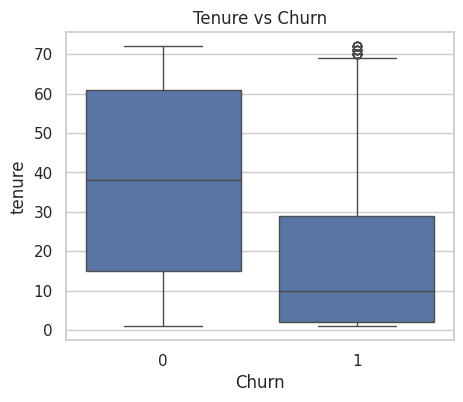

In [15]:
plt.figure(figsize=(5,4))
sns.boxplot(x=df['Churn'], y=df['tenure'])
plt.title("Tenure vs Churn")
plt.show()

Monthly Charges vs Churn

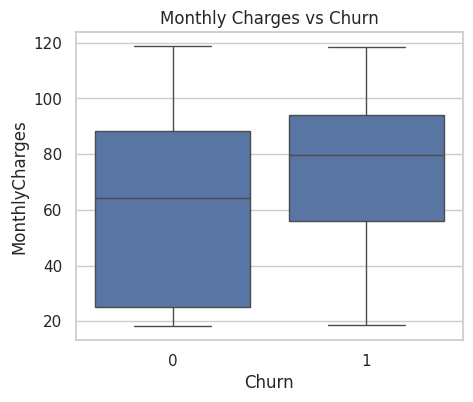

In [16]:
plt.figure(figsize=(5,4))
sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'])
plt.title("Monthly Charges vs Churn")
plt.show()

#Modeling

In [17]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#Evaluation

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.77      0.79      0.78      1407

ROC AUC Score: 0.8213


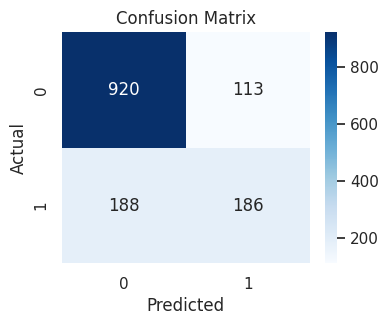

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

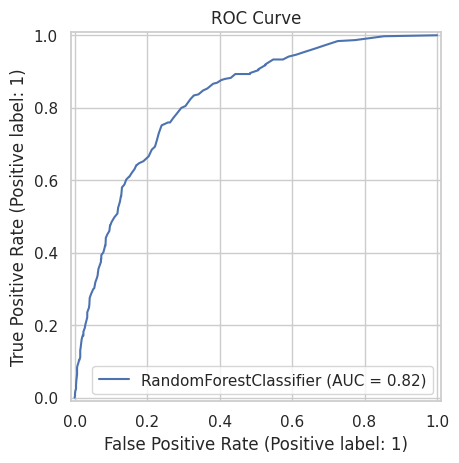

In [20]:
# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()

#Feature Importance

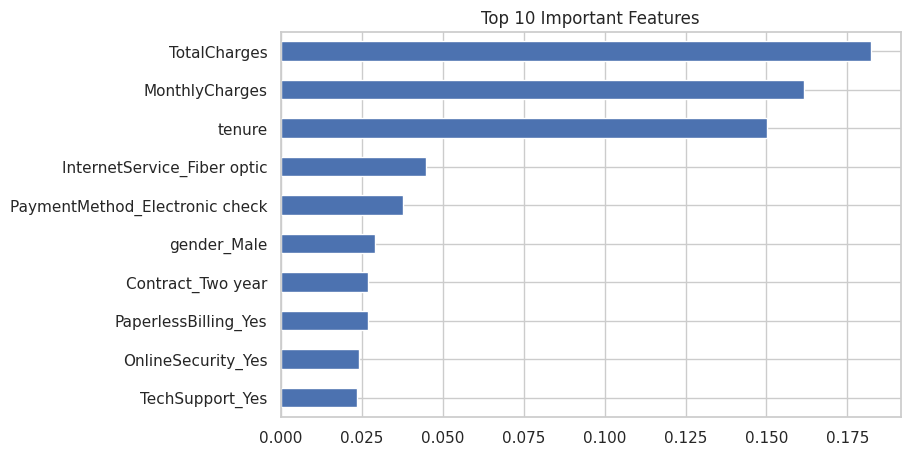


Top 10 Features:

TotalCharges                      0.182328
MonthlyCharges                    0.161480
tenure                            0.150176
InternetService_Fiber optic       0.044846
PaymentMethod_Electronic check    0.037673
gender_Male                       0.029185
Contract_Two year                 0.026941
PaperlessBilling_Yes              0.026833
OnlineSecurity_Yes                0.024107
TechSupport_Yes                   0.023701
dtype: float64


In [21]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

print("\nTop 10 Features:\n")
print(feature_importance.head(10))

Key Business Insights:

1. High-risk segment:
   Customers with tenure < 12 months show the highest churn risk
   
   → Focus on onboarding & early engagement

2. Contract impact:
   Month-to-month customers are significantly more likely to churn
   
   → Promote long-term subscriptions with incentives

3. Pricing sensitivity:
   Higher monthly charges correlate with increased churn
   
   → Improve value perception or adjust pricing strategy

4. Service support:
   Lack of tech support increases churn likelihood
   
   → Enhance customer support accessibility

5. Model-driven insight:
   Feature importance highlights key drivers of churn
   
   → Enables targeted retention strategies

In [22]:
import os

os.makedirs("outputs/plots", exist_ok=True)

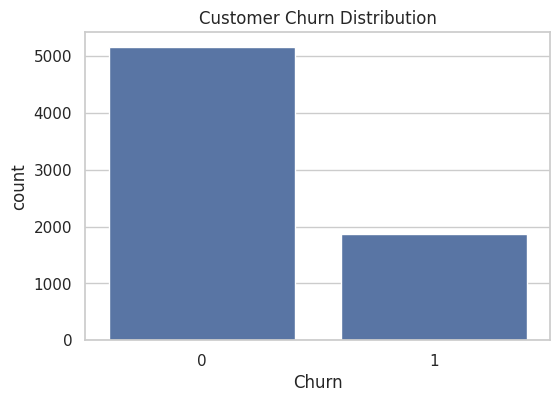

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")

plt.savefig("outputs/plots/churn_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

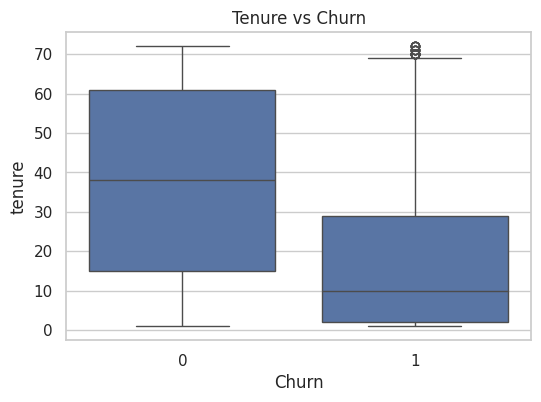

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")

plt.savefig("outputs/plots/tenure_vs_churn.png", dpi=300, bbox_inches='tight')
plt.show()

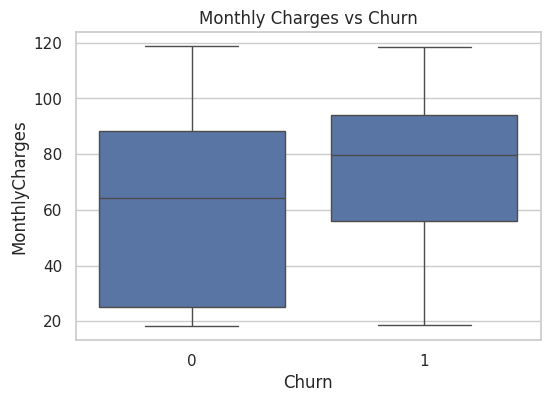

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")

plt.savefig("outputs/plots/monthly_charges_vs_churn.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
from google.colab import files
import shutil

# Zip semua plot
shutil.make_archive("plots", 'zip', "outputs/plots")

# Download
files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>